In [1]:
from google.colab import files
uploaded = files.upload()

Saving indian_liver_patient.csv to indian_liver_patient.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('indian_liver_patient.csv')

print("Shape:", df.shape)        # how many rows, columns
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (583, 11)

Columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']

First 5 rows:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values per column:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Data types:
Age                             int64
Gender                         object
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Protiens                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Dataset                         int64
dtype: object


Class distribution:
Dataset
1    416
2    167
Name: count, dtype: int64


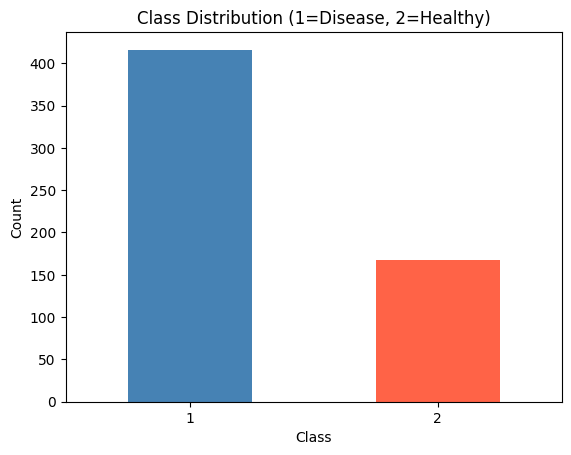

In [4]:
import matplotlib.pyplot as plt

print("Class distribution:")
print(df['Dataset'].value_counts())

df['Dataset'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution (1=Disease, 2=Healthy)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

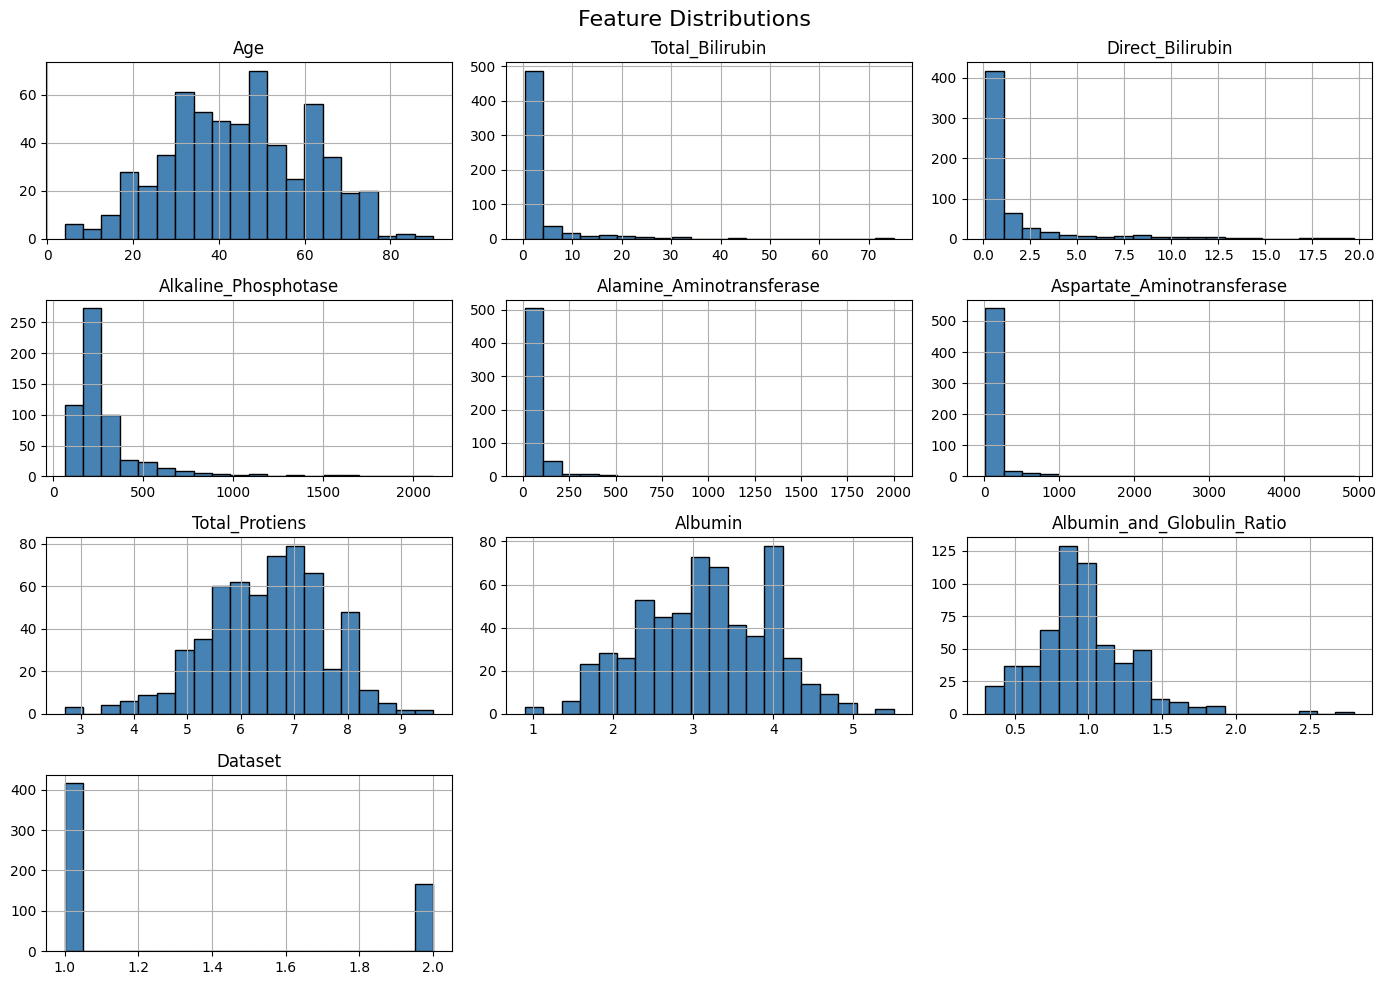

In [5]:
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

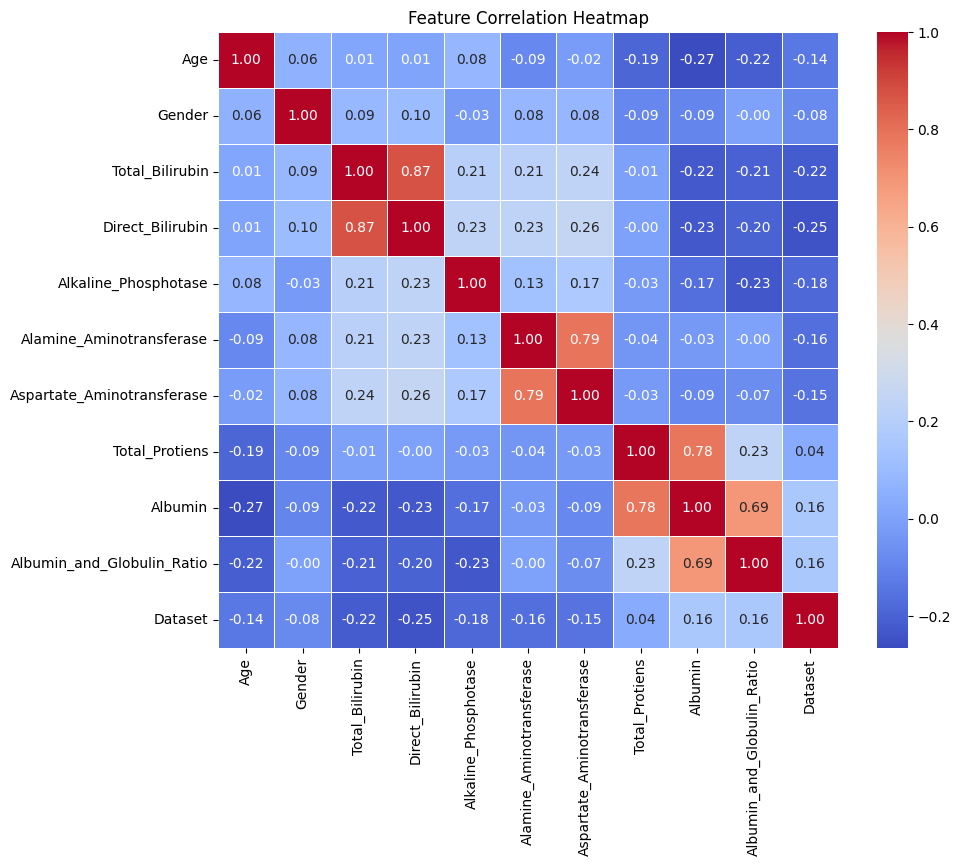

In [7]:
import seaborn as sns

# Convert Gender to numbers first (Male=1, Female=0)
df_numeric = df.copy()
df_numeric['Gender'] = df_numeric['Gender'].map({'Male': 1, 'Female': 0})

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [8]:
# Fill 4 missing values with median (not mean, because data is skewed)
df['Albumin_and_Globulin_Ratio'].fillna(
    df['Albumin_and_Globulin_Ratio'].median(), inplace=True
)

# Encode Gender: Male=1, Female=0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Fix target label: make it 0 and 1 (instead of 1 and 2)
# 1=Disease → 1, 2=Healthy → 0
df['Dataset'] = df['Dataset'].map({1: 1, 2: 0})

print("Missing values after fix:", df.isnull().sum().sum())
print("Class distribution after fix:")
print(df['Dataset'].value_counts())

Missing values after fix: 0
Class distribution after fix:
Dataset
1    416
0    167
Name: count, dtype: int64


/tmp/ipykernel_543/3337166634.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Albumin_and_Globulin_Ratio'].fillna(


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Dataset', axis=1)  # all columns except label
y = df['Dataset']               # just the label

# Split BEFORE scaling (very important — no data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit+transform on train
X_test_scaled = scaler.transform(X_test)         # only transform on test

print("Train size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)

Train size: (466, 10)
Test size: (117, 10)


In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Class weights:", class_weight_dict)
# Should show higher weight for class 0 (healthy/minority)

Class weights: {np.int64(0): np.float64(1.7518796992481203), np.int64(1): np.float64(0.6996996996996997)}
